<div style="text-align: center; padding: 20px; border-radius: 15px; background: linear-gradient(135deg, #e0f7fa, #b2ebf2); box-shadow: 0 4px 10px rgba(0,0,0,0.1);">
  <h1 style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; color: #00796b; font-size: 32px; margin-bottom: 10px;">
    Optimisation et étude de la fiabilité des installations industrielles
  </h1>
  <h2 style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; color: #004d40; font-size: 20px;">
    à l’aide d’algorithmes d’apprentissage automatique (Machine Learning)
  </h2>
</div>


<div style="font-size: 18px; color: black; margin-top: 20px; padding: 15px; border-radius: 10px; background-color: #f0f8ff; box-shadow: 0 2px 8px rgba(0,0,0,0.1);">
    <strong style="color: #004d99;">Réalisé par :</strong><br>
    <ul style="list-style: none; padding-left: 0; margin-top: 10px;">
        <li>🔹 Adsaoui Salma</li>
        <li>🔹 El Alami Oumaima</li>
        <li>🔹 Ennamous Oumayma</li>
        <li>🔹 El Ouakyl El Mehdi</li>
        <li>🔹 Afifi Saad</li>
    </ul>
    <div style="margin-top: 10px;">
        <strong style="color: #0066cc;">Classe : IID2</strong>
    </div>
</div>


# 🎯 Objectifs du projet

1. Prédire les pannes et anomalies possibles à partir des données de capteurs et de production, à l’aide d’algorithmes d’apprentissage automatique.

2. Analyser les causes des dysfonctionnements en identifiant les variables critiques responsables des différentes défaillances.

3. Suggérer des actions de maintenance préventive intelligentes pour prévenir les pannes.

# Description du Dataset

Le dataset utilisé dans ce projet concerne la surveillance de la fiabilité d’une machine de production industrielle à partir de données issues de capteurs, générées dans des conditions simulées proches de l'utilisation réelle. Chaque ligne représente un cycle de fabrication d’un produit (pièce) par cette machine, et les variables enregistrées couvrent à la fois les conditions environnementales, les paramètres opérationnels et les indicateurs de défaillance.


Les données proviennent de la plateforme Kaggle, dans le cadre de la compétition intitulée ["Binary Classification of Machine Failures"](https://www.kaggle.com/competitions/playground-series-s3e17/data).



| **Variable**                    | **Description**                                                                                                                                       |
|--------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------|
| `id`                           | Identifiant unique de chaque enregistrement (ligne) du dataset.                                                                                      |
| `Product ID`                   | Code identifiant chaque pièce ou produit usiné par la machine.                                                                                                      |
| `Type`                         | Type de produit ou catégorie de pièce. (Ex : L, M, H — souvent pour *Low*, *Medium*, *High* complexité ou criticité).                    |
| `Air temperature [K]`          | Température de l’air ambiant autour de la machine en Kelvin.                                                                                         |
| `Process temperature [K]`      | Température du processus à l’intérieur de la machine (souvent plus élevée que celle de l’air), en Kelvin.                                            |
| `Rotational speed [rpm]`       | Vitesse de rotation de la machine en tours par minute (rpm).                                                                                         |
| `Torque [Nm]`                  | Couple appliqué par la machine pendant le fonctionnement, en Newton-mètre.                                                                           |
| `Tool wear [min]`              | Durée d'usure de l’outil utilisé, mesurée en minutes. Représente la durée pendant laquelle l’outil a été utilisé.                                   |
| `Machine failure`              | `0` ou `1`. Variable binaire indiquant s’il y a eu une panne globale de la machine (`1`) ou non (`0`).                                                |
| `TWF (Tool Wear Failure)`      | `0` ou `1`. Échec dû à l'usure excessive de l'outil.                                                                                                  |
| `HDF (Heat Dissipation Failure)`| `0` ou `1`. Échec dû à un problème de dissipation thermique (surchauffe).                                                                            |
| `PWF (Power Failure)`          | `0` ou `1`. Échec dû à un problème d’alimentation électrique.                                                                                        |
| `OSF (Overstrain Failure)`     | `0` ou `1`. Échec dû à une surcharge mécanique (trop de couple, vibration, etc.).                                                                     |
| `RNF (Random Failure)`         | `0` ou `1`. Panne aléatoire non liée à un facteur mesurable spécifique — utilisée pour simuler les pannes imprévisibles.                             |


# 1. Importation des bibliothèques nécessaires

In [125]:
import pandas as pd # pandas pour la manipulation de données
import numpy as np # numpy pour les opérations numériques
import matplotlib.pyplot as plt # matplotlib pour la création de graphiques
import seaborn as sns # seaborn pour la visualisation statistique
from sklearn.metrics import confusion_matrix # sklearn.metrics pour l'évaluation des performances du modèle

In [126]:
import warnings
warnings.simplefilter("ignore")

# 2. Chargement des données

In [127]:
df = pd.read_csv('dataset.csv')

In [128]:
df.shape

(136429, 14)

In [129]:
df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


# 3. Analyse exploratoire des données (EDA)

## 1. Statistiques descriptives et informations générales

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      136429 non-null  int64  
dtypes: f

### Explication:
-  Le dataset contient 136 429 enregistrements et 14 colonnes
-  Aucune valeur manquante dans les données
-  Types de données bien définis : numériques pour les capteurs, catégorielles pou le Product ID et le type.yibe() ?


In [131]:
df.isnull().sum()

id                         0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [132]:
df.describe()

,id,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000
mean,68214.000000,299.862776,309.941070,1520.331110,40.348643,104.408901,0.015744,0.001554,0.005160,0.002397,0.003958,0.002258
std,39383.804275,1.862247,1.385173,138.736632,8.502229,63.965040,0.124486,0.039389,0.071649,0.048899,0.062789,0.047461
min,0.000000,295.300000,305.800000,1181.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34107.000000,298.300000,308.700000,1432.000000,34.600000,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,68214.000000,300.000000,310.000000,1493.000000,40.400000,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,102321.000000,301.200000,310.900000,1580.000000,46.100000,159.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,136428.000000,304.400000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Explication:

* Les variables de capteurs ont des valeurs réalistes et bien réparties.


## 2. Visualisation de la distribution des variables continues

In [133]:
continuous_vars= df.select_dtypes(include=['float64', 'int64']).columns
continuous_vars

Index(['id', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

## Distribution de fréquence des variables

In [134]:
for var in continuous_vars:
    print(f"Distribution des fréquences pour {var}:")
    print(df[var].value_counts())
    print("\n")

Distribution des fréquences pour id:
id
0         1
90948     1
90962     1
90961     1
90960     1
         ..
45471     1
45470     1
45469     1
45468     1
136428    1
Name: count, Length: 136429, dtype: int64


Distribution des fréquences pour Air temperature [K]:
Air temperature [K]
300.700    4984
297.400    4042
300.500    3707
300.600    3584
298.200    3419
           ... 
295.400      10
295.300       4
300.980       1
297.095       1
303.960       1
Name: count, Length: 95, dtype: int64


Distribution des fréquences pour Process temperature [K]:
Process temperature [K]
310.6    5159
310.8    4695
310.7    4392
308.5    4198
308.6    4165
         ... 
306.7      22
306.9      16
313.7      15
305.8      10
313.8       9
Name: count, Length: 81, dtype: int64


Distribution des fréquences pour Rotational speed [rpm]:
Rotational speed [rpm]
1452    1119
1447     937
1435     931
1418     894
1469     868
        ... 
2006       1
2617       1
2676       1
2760       1
2169    

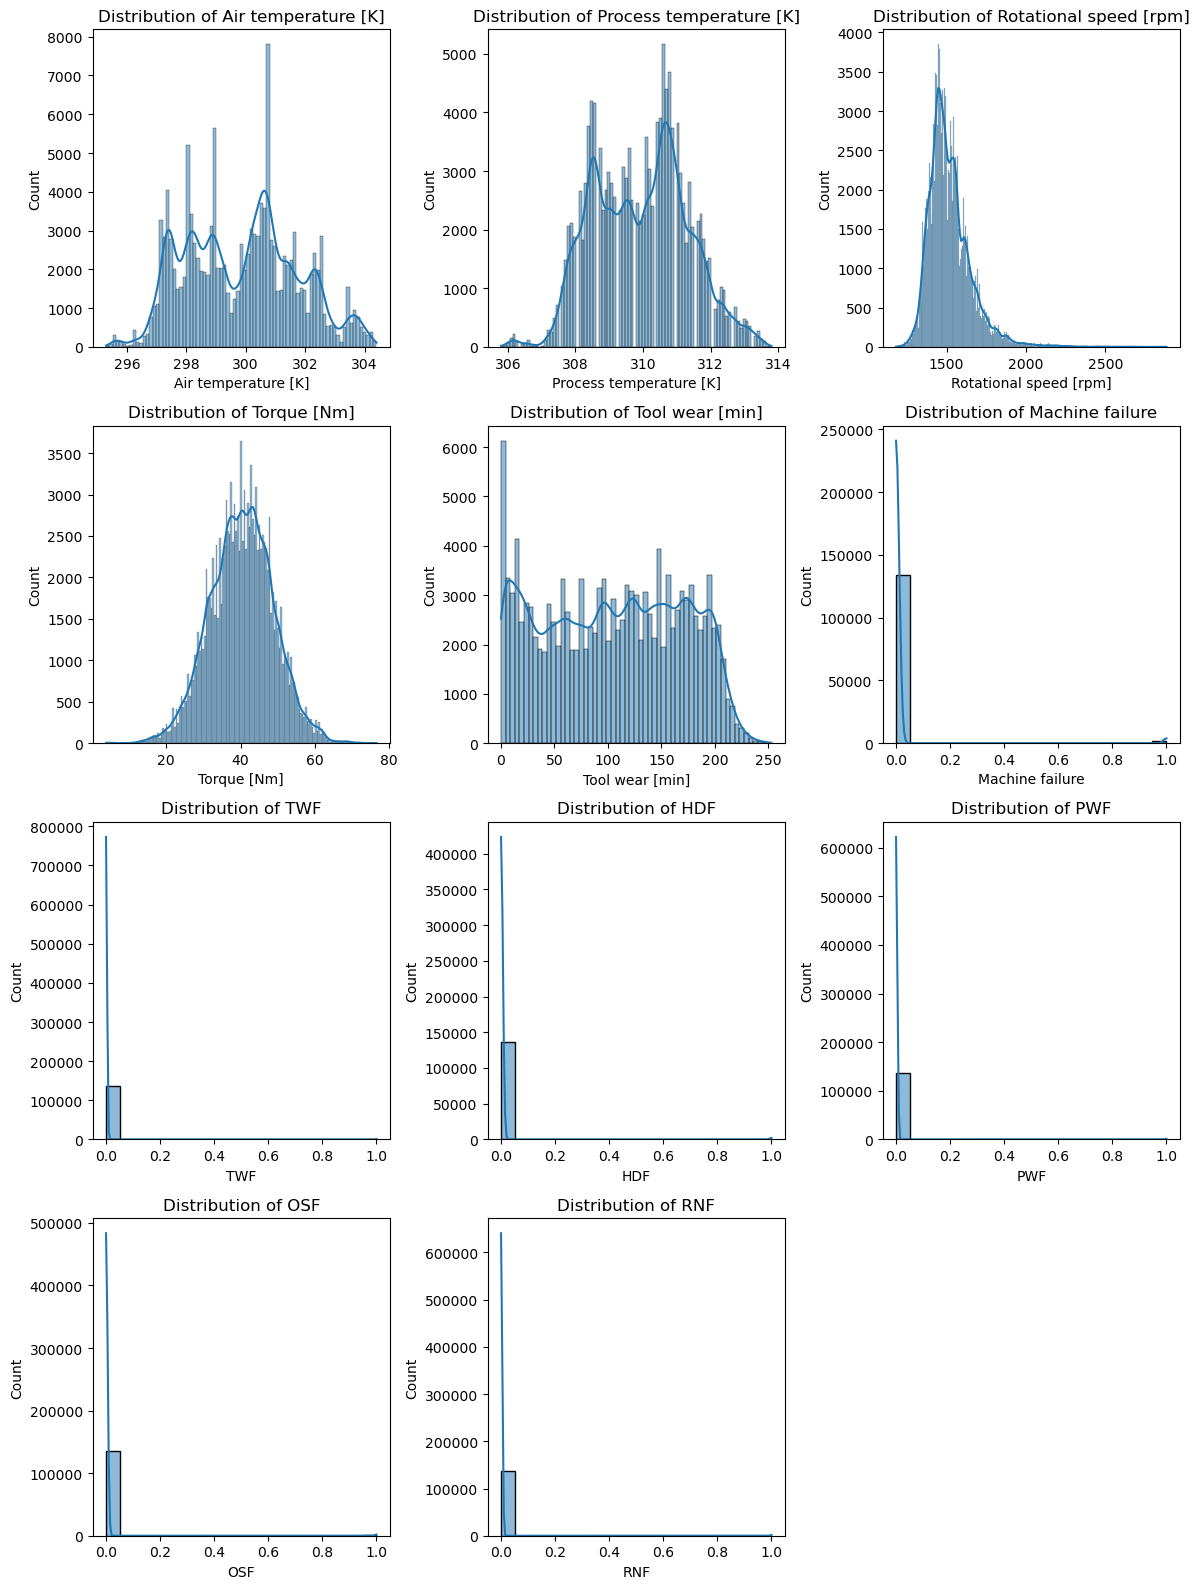

In [135]:
vars_to_plot=continuous_vars[1:]

n_vars = len(vars_to_plot)
n_cols = 3 
n_rows = np.ceil(n_vars / n_cols).astype(int)  

plt.figure(figsize=(12, n_rows * 4))
for i, var in enumerate(vars_to_plot):
    plt.subplot(n_rows, n_cols, i + 1) 
    sns.histplot(df[var], kde=True)
    plt.title(f'Distribution of {var}')
    plt.tight_layout()

plt.show()

### Explication:

* **Air temperature \[K] et Process temperature \[K]** : Les températures sont assez constantes et concentrées autour de valeurs spécifiques (environ 300 K pour **Air temperature \[K]** et 310 K pour **Process temperature \[K]**).

* **Rotational speed \[rpm]** : Il existe une variabilité avec plusieurs valeurs fréquentes, mais aussi des valeurs rares.

* **Torque \[Nm]** : Concentration autour de certaines valeurs communes, mais avec une large gamme de valeurs.

* **Tool wear \[min]** : Concentration autour de faibles valeurs d'usure (comme 0, 2, 119), mais présence de valeurs plus élevées moins fréquentes.



## Détection des valeurs aberrantes 

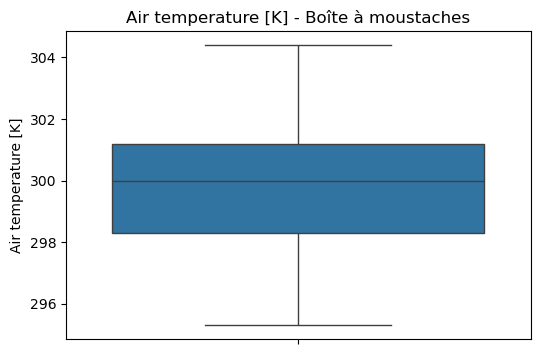

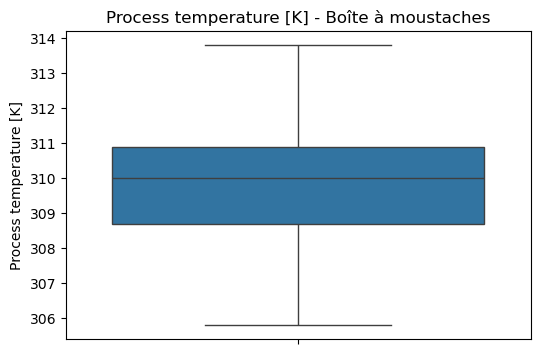

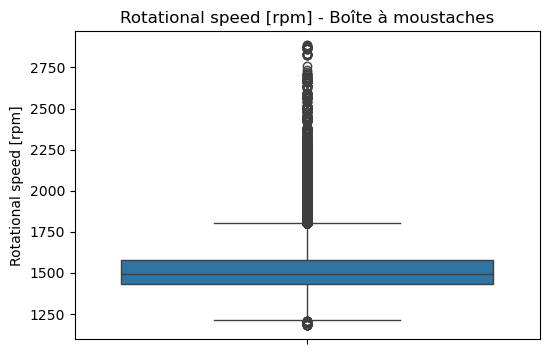

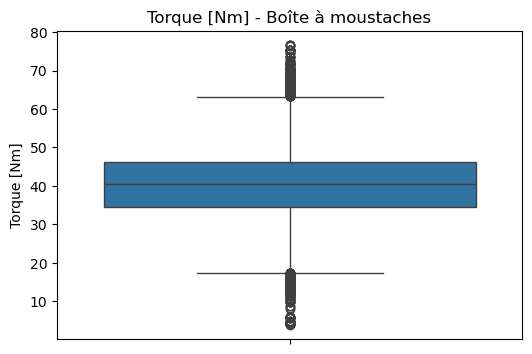

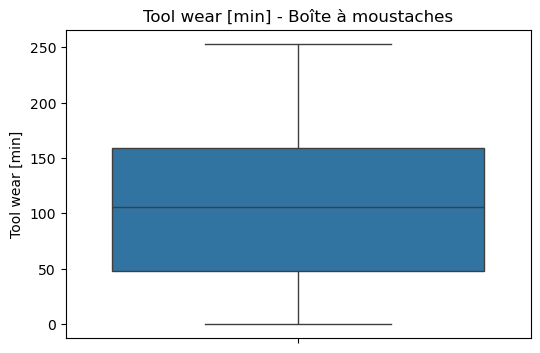

In [136]:
cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

# Créer un boxplot pour chaque variable dans cols
for col in cols:
    plt.figure(figsize=(6, 4))  # Définir la taille de la figure
    sns.boxplot(y=df[col])  # Afficher un boxplot de la variable col
    plt.title(f'{col} - Boîte à moustaches')  # Ajouter un titre
    plt.show()  # Afficher le graphique

In [137]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f'{col} : {len(outliers)} valeurs aberrantes détectées')


Air temperature [K] : 0 valeurs aberrantes détectées
Process temperature [K] : 0 valeurs aberrantes détectées
Rotational speed [rpm] : 5159 valeurs aberrantes détectées
Torque [Nm] : 1060 valeurs aberrantes détectées
Tool wear [min] : 0 valeurs aberrantes détectées


### Explication:
La majorité des variables sont bien réparties sans valeurs extrêmes, à l’exception de la vitesse de rotation et du couple qui présentent un grand nombre de valeurs aberrantes à traiter. Cela suggère une forte variabilité ou des anomalies possibles dans le fonctionnement de la machine pour ces deux paramètres.

## Matrice de corrélation pour analyser les relations linéaires entre les variables

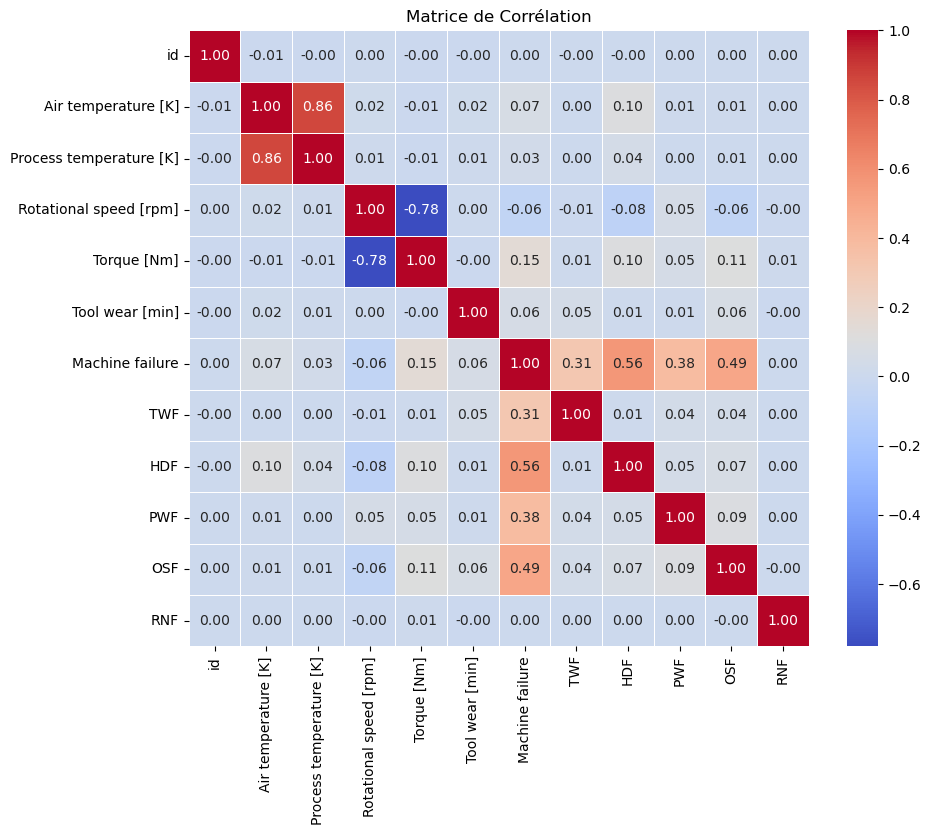

In [138]:
corr_matrix = df[continuous_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Matrice de Corrélation")
plt.show()


### Explication:

#### Faible corrélation avec les variables continues :

Les variables comme Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm] ou Tool wear [min] ont toutes une corrélation faible (< 0.2) avec Machine failure.

Cela indique que la panne globale (Machine failure) n’est pas fortement corrélée directement avec une seule variable numérique.

#### Corrélations intéressantes avec les types de pannes spécifiques :

Machine failure est modérément corrélée avec :

- TWF (0.31)
- HDF (0.56)
- PWF (0.38)
- OSF (0.49)

Cela est logique, car Machine failure = 1 signifie qu’au moins une de ces défaillances spécifiques (TWF**, HDF, etc.) a eu lieu.

Ces colonnes peuvent donc être des bons prédicteurs de la panne globale — ou du moins, des composants explicatifs directs.

#### Corrélations entre features :

- Air temperature [K] et Process temperature [K] ont une forte corrélation positive (0.86) : cela indique une redondance potentielle entre ces deux variables.
  
- Corrélation négative forte entre Rotational speed et Torque (-0.78) : Cela peut refléter une relation physique logique : à vitesse plus élevée, le couple peut diminuer selon le type d’opération.


## 3. Visualisation de la distribution des variables Catégorielles

## Distribution de fréquence du variable Type

In [139]:
df["Type"].value_counts()

Type
L    95354
M    32152
H     8923
Name: count, dtype: int64

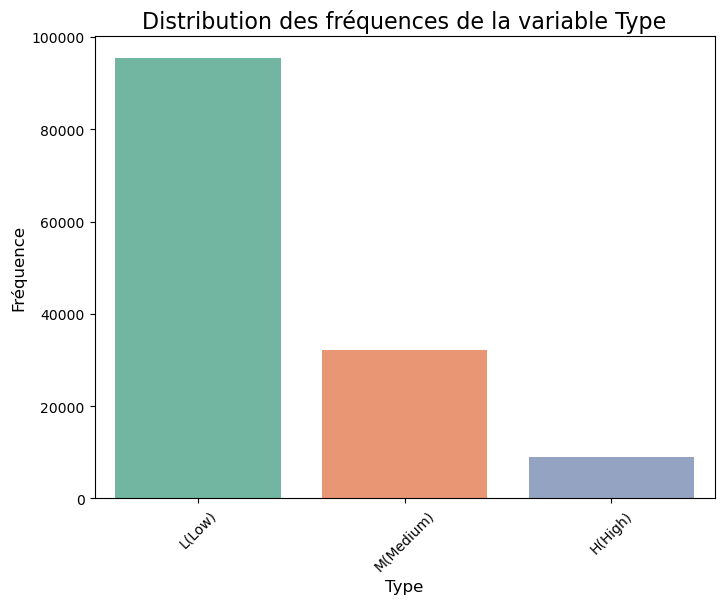

In [140]:
label_dict = {
    'L': 'L(Low)',
    'M': 'M(Medium)',
    'H': 'H(High)'
}

df['Type'] = df['Type'].replace(label_dict)

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Type', palette='Set2')

plt.title('Distribution des fréquences de la variable Type', fontsize=16)
plt.xlabel('Type', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)

plt.xticks(rotation=45)

plt.show()


## Explication :

La variable "Type" présente un déséquilibre marqué avec la majorité des données dans la catégorie L (Low), suivie de M (Medium) et très peu de données pour H (High).Ce déséquilibre pourrait affecter les modèles prédictifs.

## Relation entre le type de produit fabriqué et les défaillances de la machine (Machine Failure)

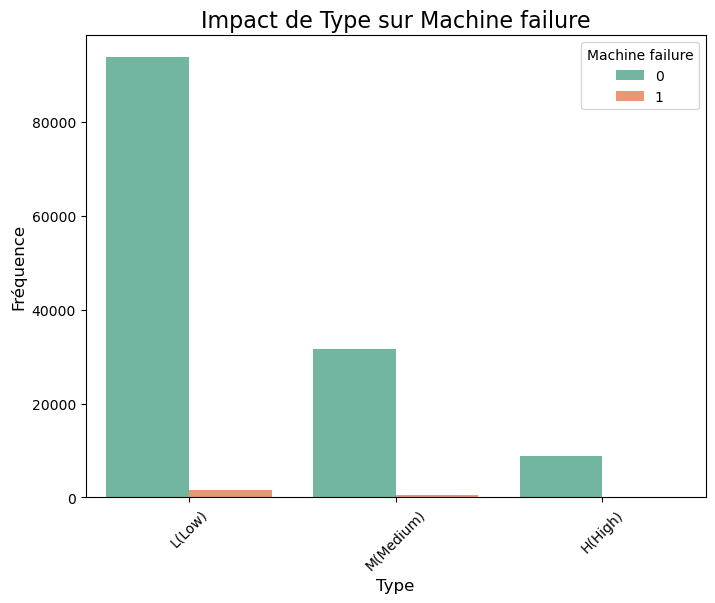

In [141]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Type', hue='Machine failure', palette='Set2')

plt.title('Impact de Type sur Machine failure', fontsize=16)
plt.xlabel('Type', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)

plt.xticks(rotation=45)  # Rotation des labels de l'axe x si nécessaire
plt.show()

In [142]:
taux_panne_par_type = df.groupby('Type')['Machine failure'].mean().reset_index()

taux_panne_par_type.columns = ['Type', 'Taux de panne']
taux_panne_par_type


,Type,Taux de panne
0,H(High),0.013000
1,L(Low),0.016727
2,M(Medium),0.013592


### Explication:
Les pannes (Machine failure = 1) sont très rares dans toutes les catégories de Type, mais semblent légèrement plus fréquentes proportionnellement chez les machines de type L (Low). Cela suggère que ces machines sont un peu plus sujettes aux pannes, toutefois, la différence entre les types reste relativement faible, ce qui indique que le type n’est probablement pas un facteur déterminant majeur dans les défaillances globales.

# 4. Préparation des données

In [143]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


## Suppression des colonnes non pertinentes pour la prédiction
'id' et 'Product ID' sont souvent des identifiants uniques, donc non informatifs pour l'apprentissage

In [144]:
df = df.drop(columns=['id', 'Product ID'])

## Gestion des valeurs aberrantes

Méthode : IQR = Q3 - Q1. On filtre les points hors de [Q1 - 1.5×IQR, Q3 + 1.5×IQR]

In [145]:
def winsorize_feature(df, feature):
    """Limite les valeurs extrêmes à l'intérieur des bornes IQR (Winsorization)"""
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Remplacer les valeurs trop basses/hautes par les bornes
    df[feature] = np.where(df[feature] < lower_bound, lower_bound, df[feature])
    df[feature] = np.where(df[feature] > upper_bound, upper_bound, df[feature])
    return df


In [146]:
# Appliquer la Winsorization sur les colonnes avec valeurs aberrantes
for col in ['Rotational speed [rpm]', 'Torque [Nm]']:
    df = winsorize_feature(df, col)


In [147]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f'{col} : {len(outliers)} valeurs aberrantes détectées')

Air temperature [K] : 0 valeurs aberrantes détectées
Process temperature [K] : 0 valeurs aberrantes détectées
Rotational speed [rpm] : 0 valeurs aberrantes détectées
Torque [Nm] : 0 valeurs aberrantes détectées
Tool wear [min] : 0 valeurs aberrantes détectées


## Séparation des features et de la cible
Définition de la cible (y) et des features explicatives (X)

In [148]:
 # étiquette à prédire (binaire : panne ou pas)
target_col = 'Machine failure'    
y = df[target_col]
X = df.drop(columns=[
    target_col,
    'TWF', 'HDF', 'PWF', 'OSF', 'RNF'  
])

## Identification des colonnes numériques et catégorielles
Cela permet de construire des transformations adaptées à chaque type de donnée

In [149]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['number']).columns.tolist() 

## Construction du pipeline pour colonnes numériques
gérer les valeurs manquantes (par la moyenne) puis normaliser les données (centrées réduites)

In [150]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),      # imputation des valeurs manquantes numériques
    ('scaler', StandardScaler())                      # normalisation standard (z-score)
])


## Construction du pipeline pour colonnes catégorielles
imputer les valeurs manquantes (par la valeur la plus fréquente), puis encoder les catégories

In [151]:
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # imputation des catégories manquantes
    ('encoder', OneHotEncoder(drop=None, handle_unknown='ignore'))  # encodage en variables binaires
]) 

## Fusion des deux pipelines via ColumnTransformer
On applique le pipeline numérique aux colonnes numériques et le pipeline catégoriel aux colonnes catégorielles

In [152]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ]
)


In [153]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Air temperature [K]',
                                  'Process temperature [K]',
                                  'Rotational speed [rpm]', 'Torque [Nm]',
                                  'Tool wear [min]']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Type'])])

## Découpage du dataset en train/test (80% entraînement, 20% test)
La stratification garantit la même proportion de classes (fail/ok) dans chaque échantillon

In [154]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y )


## Application de la transformation à l’ensemble d’entraînement et de test
- fit_transform sur X_train_raw : le préprocesseur apprend comment transformer les données  (par exemple, normaliser ou encoder) et applique cette transformation à X_train_raw
- transform sur X_test_raw : on applique exactement les mêmes transformations à X_test_raw, sans refaire l’apprentissage sur ces données.

Cela permet de préparer correctement les données pour entraîner et tester le modèle.s.


In [155]:
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

In [156]:
print("Pipeline appliquée avec succès.")
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)

Pipeline appliquée avec succès.
X_train shape : (109143, 8)
X_test shape  : (27286, 8)


## Sauvegarde du pipeline pour réutilisation future
utile pour l'utiliser lors du déploiement ou pour réutilisation en production

In [157]:
import joblib
joblib.dump(preprocessor, 'preprocessing_pipeline.joblib')  

['preprocessing_pipeline.joblib']

## Etape 4: Modélisation pour prédiction de pannes


# Pourquoi Random Forest est un bon choix initial ?

Résistant au surapprentissage (grâce au bagging et l’agrégation d’arbres)

Gère bien les variables numériques et catégorielles (sans beaucoup de prétraitement)

Robuste aux valeurs manquantes et aux outliers

Explique bien l’importance des variables, pratique pour interpréter quels facteurs influencent les pannes

Performance correcte même sans ajuster beaucoup d’hyperparamètres

In [158]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

*La prediction des pannes sur l'ensemble de test*

In [159]:
y_pred = model.predict(X_test)
joblib.dump(model, 'model_random_forest.joblib') 

['model_random_forest.joblib']

In [160]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

*Accurancy: c’est le pourcentage de bonnes prédictions faites par le modèle, sur l’ensemble des prédictions*


*Le F1-score est une métrique d’évaluation qui combine précision (precision) et rappel (recall) en un seul nombre.*

**Precision:** 
- Precision = proportion des prédictions positives qui sont correctes 
***TP/TP+FP***

**Recall**
- Recall(sensibilité) = proportion des cas réellement positifs bien détectés* 
***TP/TP+FN***

***F1 = 2 * [(Precison * Recall) / (Precison + Recall)]***

In [161]:
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9856
F1-score: 0.9829


*Matrice de Confusion: est un tableau qui montre où le modèle s’est trompé ou a bien prédit, en croisant les valeurs réelles et les valeurs prédites.*

- **TP (True Positive)** = le modèle prédit panne et c’est vraiment une panne

- **TN (True Negative)** = le modèle prédit pas panne et c’est vrai

- **FP (False Positive)** = le modèle prédit panne mais en réalité il n’y a pas de panne

- **FN (False Negative)** = le modèle prédit pas panne alors qu’il y a une panne

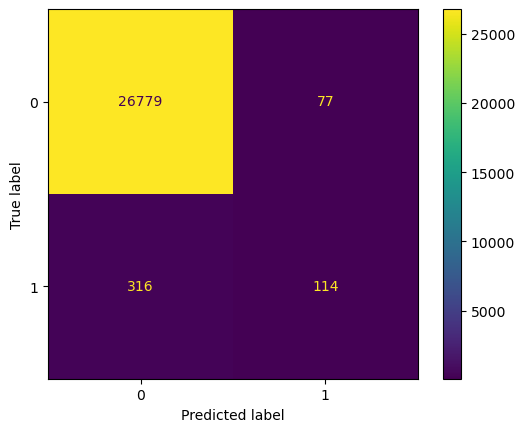

In [162]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# **ÉTAPE 5 – Analyse des causes des pannes**

**Objectif :**

 * Comprendre quelles variables influencent le plus la survenue d’une panne (variable cible Machine failure)
 
→ Interprétabilité du modèle pour une maintenance prédictive intelligente.

In [163]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import shap

### **5.1 - Importance des variables (feature_importances_)**

- **Charger le modèle .joblib**

In [164]:
rf_model = joblib.load("model_random_forest.joblib") 

In [165]:
print(rf_model.n_features_in_)  # Number of input features

8


- **Récupération des noms de colonnes**

In [166]:
feature_names = preprocessor.get_feature_names_out()
feature_names 

array(['num__Air temperature [K]', 'num__Process temperature [K]',
       'num__Rotational speed [rpm]', 'num__Torque [Nm]',
       'num__Tool wear [min]', 'cat__Type_H(High)', 'cat__Type_L(Low)',
       'cat__Type_M(Medium)'], dtype=object)

- **Extraire l’importance des features et associer chaque importance à son nom de colonne**

In [167]:
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances , feature_names) 
feat_importances

num__Air temperature [K]        0.170330
num__Process temperature [K]    0.152587
num__Rotational speed [rpm]     0.210829
num__Torque [Nm]                0.256035
num__Tool wear [min]            0.188903
cat__Type_H(High)               0.005023
cat__Type_L(Low)                0.008748
cat__Type_M(Medium)             0.007545
dtype: float64

- **Trier et visualiser**

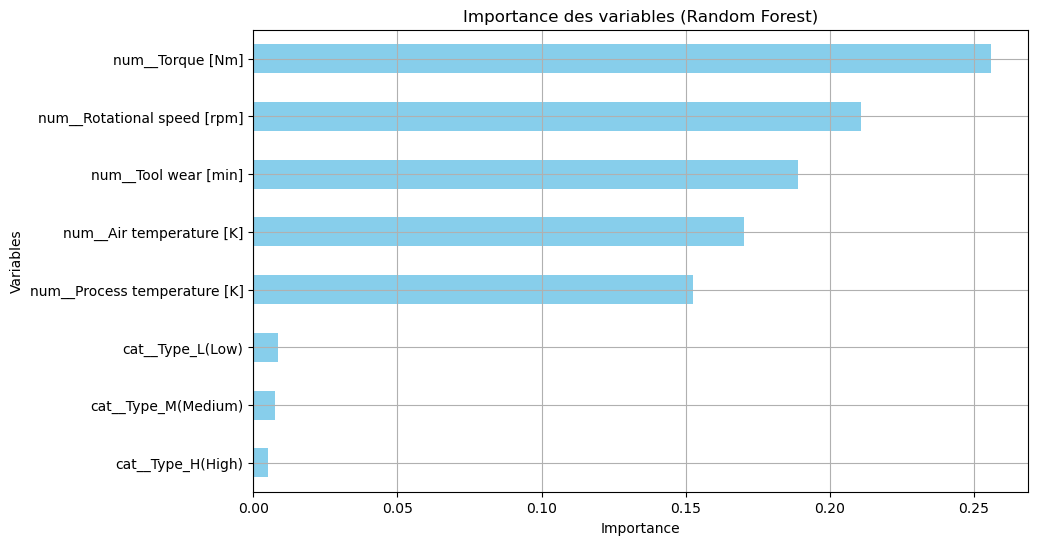

In [168]:
feat_importances.sort_values(ascending=True).plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title("Importance des variables (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.grid(True)
plt.show()

Cela permet d'identifier quelles variables influencent le plus les prédictions de pannes. Exemple :

| Variable                     | Interprétation                                                                                      |
| ---------------------------- | --------------------------------------------------------------------------------------------------- |
| **Torque \[Nm]**             | ➤ **Variable la plus influente** — Un couple élevé pourrait augmenter les risques de panne.         |
| **Rotational speed \[rpm]**  | ➤ Impact très fort aussi — Une vitesse de rotation élevée influence fortement la prédiction.        |
| **Tool wear \[min]**         | ➤ L’usure de l’outil est aussi critique — Un outil usé est plus susceptible de provoquer une panne. |
| **Air temperature \[K]**     | ➤ A un certain effet — Une température ambiante élevée peut influencer les défaillances.            |
| **Process temperature \[K]** | ➤ Similaire à l’air ambiant — Chaleur excessive dans le processus est un facteur notable.           |
| **Type (Heigh/Low/Medium)**        | ➤ Moins d’impact — Le type de produit semble moins important dans les prédictions du modèle.        |


### **5.2 - Interprétabilité avancée avec SHAP**

- **SHAP** *(SHapley Additive exPlanations)* : est une méthode d'interprétabilité des modèles de Machine Learning, qui permet de comprendre l'importance et l'effet de chaque variable (feature) sur une prédiction donnée.

In [169]:
! pip install shap

- **un explainer SHAP pour RandomForest**

**Le graphique montre comment différentes caractéristiques influencent les prédictions du modèle Random Forest.**

- Imaginez que vous avez un modèle qui prédit quelque chose (comme une probabilité) et vous voulez savoir quelles caractéristiques sont importantes pour cette prédiction.

**Explication simple du graphique SHAP:**

- *Les points colorés:* Chaque point représente une donnée (une observation)

- Points **rouges** = valeurs élevées de cette caractéristique
- Points **bleus** = valeurs faibles de cette caractéristique


# Test

In [170]:
# Construire un DataFrame brut avec les bonnes colonnes
test_df = pd.DataFrame([{
    'Air temperature [K]': 350,
    'Process temperature [K]': 350,
    'Rotational speed [rpm]': 1500,
    'Torque [Nm]': 150,
    'Tool wear [min]': 200,
    'Type': 'H'  
}])

X_test_transformed = preprocessor.transform(test_df)
prediction = rf_model.predict(X_test_transformed)
proba = rf_model.predict_proba(X_test_transformed)[0]

if prediction[0] == 1:
    print(f"Panne prévue avec une probabilité de {proba[1]*100:.2f}%")
else:
    print(f"Aucune panne prévue (probabilité : {proba[0]*100:.2f}%)")


Panne prévue avec une probabilité de 65.83%


In [171]:
# Créer un explainer pour le modèle
explainer = shap.TreeExplainer(rf_model)

# Calcul des SHAP values pour cette observation
shap_values = explainer.shap_values(X_test_transformed)

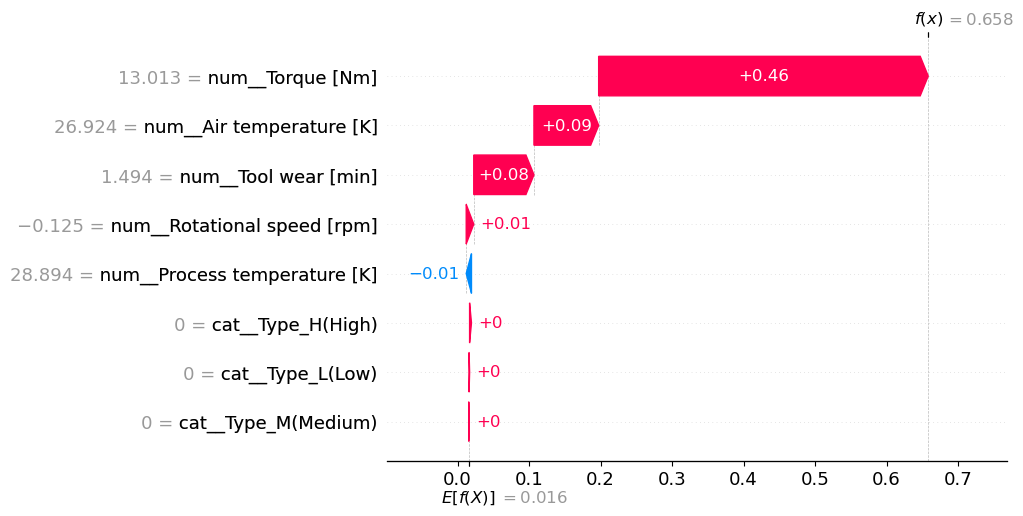

In [172]:
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0, :, prediction[0]],  # 0e observation, toutes les features, class prédite
    base_values=explainer.expected_value[prediction[0]],  # Valeur de base pour la classe prédite
    data=X_test_transformed[0],
    feature_names=feature_names
))

In [173]:
instance_idx = 0
class_idx = prediction[0]
shap_vals = shap_values[instance_idx, :, class_idx]
base_value = explainer.expected_value[class_idx]
features = X_test_transformed[instance_idx]
names = feature_names
model_output = base_value + shap_vals.sum()

print(f"Valeur de base (baseline): {base_value:.4f}")
print(f"Prédiction finale du modèle: {model_output:.4f}\n")
print("Impact des variables :")

sorted_idx = np.argsort(np.abs(shap_vals))[::-1]

for i in sorted_idx:
    sign = "+" if shap_vals[i] >= 0 else "-"
    print(f"  {names[i]} = {features[i]} : {sign}{abs(shap_vals[i]):.4f}")


Valeur de base (baseline): 0.0157
Prédiction finale du modèle: 0.6583

Impact des variables :
  num__Torque [Nm] = 13.013074353141267 : +0.4609
  num__Air temperature [K] = 26.923647692624193 : +0.0905
  num__Tool wear [min] = 1.4936738014067223 : +0.0842
  num__Rotational speed [rpm] = -0.12486598449131939 : +0.0105
  num__Process temperature [K] = 28.893940513208644 : -0.0073
  cat__Type_H(High) = 0.0 : +0.0026
  cat__Type_L(Low) = 0.0 : +0.0007
  cat__Type_M(Medium) = 0.0 : +0.0004


> **Analyse des causes de panne**

*Valeur de base (base value) :* E[f(X)] = 0.016

- C’est la probabilité moyenne de panne dans l’ensemble des données.

*Prédiction finale :* ≈ 0.62
- Donc le modèle a estimé une probabilité de panne de ~62% pour cette machine.


| Feature                        | Valeur | Impact SHAP | Interprétation                                                                          |
| ------------------------------ | ------ | ----------- | --------------------------------------------------------------------------------------- |
| `num__Torque [Nm]`             | 13.01  | **+0.4609** |🔴 Très fort **effet positif** : cette valeur de couple augmente fortement la prédiction.  |
| `num__Air temperature [K]`     | 53.77  | **+0.0905** |🔴 L'air plus chaud contribue modérément à augmenter la prédiction.                        |
| `num__Tool wear [min]`         | 1.49   | **+0.0842** |🔴 L’usure de l’outil dans cet intervalle est également un facteur qui augmente la sortie. |
| `num__Rotational speed [rpm]`  | -0.12  | **+0.0105** |🟠 Petite influence positive (même si la valeur est négative).                             |
| `num__Process temperature [K]` | 28.89  | **–0.0073** |🟠 Légère réduction de la prédiction finale, influence négative.                           |
| `cat__Type_H(High)`            | 0.0    | **+0.0026** |🟢 Cette machine n'est **pas** de type High, mais cela a une très faible influence.        |
| `cat__Type_L(Low)`             | 0.0    | **+0.0007** |⚪ Idem, peu d’effet.                                                                      |
| `cat__Type_M(Medium)`          | 0.0    | **+0.0004** |⚪ Idem, peu d’effet.                                                                      |


La prédiction est **0.6583**, bien supérieure à la moyenne (0.0157), ce qui indique que cette instance est très atypique ou à risque élevé selon le modèle.

**Les deux variables les plus influentes sont :**

- *Le couple (Torque) :* +0.4609

- *La température de l’air :* +0.0905

Les autres variables ont un effet mineur mais peuvent cumuler pour ajuster légèrement la prédiction.

**La valeur élevée du couple (Torque)** est le facteur principal responsable de la prédiction d'une panne.

# **Étape 6 : Stratégie de maintenance intelligente**
  <p>
    Cette étape vise à exploiter les prédictions du modèle d'apprentissage automatique
    pour proposer des actions de maintenance préventive intelligentes. L'objectif est de réduire les pannes, optimiser la durée 
    de vie des équipements et minimiser les arrêts non planifiés.
  </p>

  <h2>6.1 Stratégie de maintenance préventive</h2>


  <h3>6.2.1 Surveillance en temps réel</h3>
  <h4>Seuils d'alerte dynamiques</h4>
  <ul>
    <li>Couple : Alerte si &gt; 120 Nm (surcharge potentielle)</li>
    <li>Usure de l'outil : Alerte si &gt; 160 min (80% de la durée de vie)</li>
    <li>Vitesse de rotation : Alerte si &gt; 1800 rpm</li>
  </ul>

  <h2>6.3 Implémentation pratique</h2>
  <h3>6.3.1 Intégration du modèle</h3>
  <ul>
    <li>Déploiement via API (ex. : FastAPI) pour prédictions en temps réel</li>
  </ul>

<h3>6.3.2 Système d’alerte</h3>
  <ul>
    <li>Notifications automatiques (email, SMS) si probabilité de panne &gt; 50%</li>
    <li>Exemple : "Alerte : Couple = 150 Nm, risque de panne élevé. Vérifier immédiatement."</li>
  </ul>


In [ ]:
from fastapi import FastAPI, HTTPException 
from pydantic import BaseModel 
import numpy as np 
import pandas as pd 
import joblib 
import shap  
import smtplib 
import os
from email.mime.text import MIMEText 
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

app = FastAPI()

try:
    model = joblib.load("model_random_forest.joblib")
    preprocessor = joblib.load("preprocessing_pipeline.joblib")
    logger.info("Model and preprocessor loaded successfully")
except Exception as e:
    logger.error(f"Failed to load model or preprocessor: {e}")
    raise

try:
    explainer = shap.TreeExplainer(model)
    logger.info("SHAP explainer initialized successfully")
    logger.info(f"Expected value shape: {np.shape(explainer.expected_value)}")
except Exception as e:
    logger.error(f"Failed to initialize SHAP explainer: {e}")
    raise

thresholds = {
    'Torque [Nm]': 120,
    'Tool wear [min]': 160,
    'Rotational speed [rpm]': 1800
}

class SensorData(BaseModel):
    torque: float
    tool_wear: float
    rotational_speed: float
    air_temperature: float
    process_temperature: float
    type: str

def send_email_alert(subject, body, to_email):
    """Envoie une alerte par email si la configuration SMTP est disponible."""
    smtp_host = os.getenv("SMTP_HOST", "sandbox.smtp.mailtrap.io")
    smtp_port = int(os.getenv("SMTP_PORT", "2525"))
    smtp_user = os.getenv("SMTP_USER")
    smtp_password = os.getenv("SMTP_PASSWORD")
    from_email = os.getenv("SMTP_FROM_EMAIL")

    if not all((smtp_user, smtp_password, from_email, to_email)):
        logger.warning("Email alert skipped: SMTP settings or ALERT_EMAIL are missing")
        return

    msg = MIMEText(body)
    msg['Subject'] = subject
    msg['From'] = from_email
    msg['To'] = to_email

    try:
        with smtplib.SMTP(smtp_host, smtp_port) as server:
            server.starttls()
            server.login(smtp_user, smtp_password)
            server.sendmail(from_email, to_email, msg.as_string())
        logger.info(f"Email envoyé à {to_email} via SMTP: {subject}")
    except Exception as e:
        logger.error(f"Erreur envoi email via SMTP: {e}")

def generate_alerts(probability, shap_values, feature_names, observation, thresholds, to_email):
    """Génère des alertes si la probabilité ou les seuils sont dépassés."""
    alerts = []

    if probability > 0.5:
        alert = f"Alerte critique : Probabilité de panne = {probability:.2%}"
        alerts.append(alert)
        logging.warning(alert)

    for i, feature in enumerate(feature_names):
        shap_value = shap_values[i]
        feature_value = observation[i]

        if feature in thresholds and feature_value > thresholds[feature] and shap_value > 0.05:
            alert = (
                f"Alerte : {feature} = {feature_value} (SHAP = {shap_value:.2f}) "
                f"dépasse le seuil ({thresholds[feature]}). Action : Vérifier {feature.lower()}."
            )
            alerts.append(alert)
            logging.warning(alert)

    if alerts:
        body = "\n".join(alerts)
        send_email_alert("Alerte de maintenance", body, to_email)

    return alerts

@app.post("/predict")
async def predict_failure(data: SensorData):
    try:
        logger.info(f"Received input: {data.dict()}")

        if data.type not in ['L', 'M', 'H']:
            logger.error(f"Invalid type: {data.type}. Must be 'L', 'M', or 'H'")
            raise HTTPException(status_code=400, detail="Type must be 'L', 'M', or 'H'")

        numeric_inputs = [data.torque, data.tool_wear, data.rotational_speed,
                         data.air_temperature, data.process_temperature]
        if all(x == 0.0 for x in numeric_inputs):
            logger.error("All numeric inputs are zero")
            raise HTTPException(status_code=400, detail="Numeric inputs cannot all be zero")

        input_data = pd.DataFrame([[
            data.air_temperature, data.process_temperature, data.rotational_speed,
            data.torque, data.tool_wear, data.type
        ]], columns=[
            'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
            'Torque [Nm]', 'Tool wear [min]', 'Type'
        ])

        observation = np.array([
            data.torque, data.tool_wear, data.rotational_speed,
            data.air_temperature, data.process_temperature,
            1 if data.type == 'L' else 0,
            1 if data.type == 'M' else 0,
            1 if data.type == 'H' else 0
        ])

        try:
            input_transformed = preprocessor.transform(input_data)
            logger.info(f"Input transformed successfully: shape={input_transformed.shape}")
        except Exception as e:
            logger.error(f"Preprocessing error: {e}")
            raise HTTPException(status_code=500, detail=f"Preprocessing error: {str(e)}")

        if np.any(np.isnan(input_transformed)):
            logger.error("Transformed input contains NaN values")
            raise HTTPException(status_code=400, detail="Transformed input contains NaN values")

        prob = model.predict_proba(input_transformed)[0][1]
        logger.info(f"Prediction made: failure_probability={prob:.4f}")

        if prob < 0.01:
            logger.warning("Prediction probability is very low. Verify input data and model.")

        shap_values = explainer.shap_values(input_transformed)
        logger.info(f"SHAP values type: {type(shap_values)}, shape: {np.shape(shap_values)}")

        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        elif shap_values.ndim == 3:
            shap_values = shap_values[:, :, 1]
        if shap_values.ndim == 1:
            shap_values = shap_values.reshape(1, -1)

        feature_names = [
            'Torque [Nm]', 'Tool wear [min]', 'Rotational speed [rpm]',
            'Air temperature [K]', 'Process temperature [K]', 'Type = L', 'Type = M', 'Type = H'
        ]
        shap_contributions = {
            col: float(shap_values[0][i]) for i, col in enumerate(feature_names)
        }

        logger.info(f"Accessing expected_value: shape={np.shape(explainer.expected_value)}, value={explainer.expected_value}")
        if isinstance(explainer.expected_value, np.ndarray):
            if len(explainer.expected_value) == 2:
                base_value = float(explainer.expected_value[1])
                logger.info(f"Base value extracted: {base_value}")
            else:
                logger.error(f"Unexpected expected_value length: {len(explainer.expected_value)}")
                raise HTTPException(status_code=500, detail="Invalid SHAP expected value structure")
        else:
            base_value = float(explainer.expected_value)
            logger.info(f"Base value extracted (scalar): {base_value}")

        to_email = os.getenv("ALERT_EMAIL")
        alerts = generate_alerts(prob, shap_values[0], feature_names, observation, thresholds, to_email)

        return {
            "failure_probability": prob,
            "shap_contributions": shap_contributions,
            "base_value": base_value,
            "alerts": alerts
        }

    except Exception as e:
        logger.error(f"Error in prediction: {e}")
        raise HTTPException(status_code=500, detail=f"Prediction error: {str(e)}")

2025-05-23 09:08:45,256 - INFO - Model and preprocessor loaded successfully
2025-05-23 09:08:45,300 - INFO - SHAP explainer initialized successfully
2025-05-23 09:08:45,300 - INFO - Expected value shape: (2,)


In [175]:
! pip install nest_asyncio

In [176]:
if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="127.0.0.1", port=8000)

INFO:     Started server process [54732]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)
2025-05-23 09:09:13,844 - INFO - Received input: {'torque': 200.0, 'tool_wear': 200.0, 'rotational_speed': 1500.0, 'air_temperature': 600.0, 'process_temperature': 350.0, 'type': 'H'}
2025-05-23 09:09:13,861 - INFO - Input transformed successfully: shape=(1, 8)
2025-05-23 09:09:13,867 - INFO - Prediction made: failure_probability=0.6583
2025-05-23 09:09:13,918 - INFO - SHAP values type: <class 'numpy.ndarray'>, shape: (1, 8, 2)
2025-05-23 09:09:13,933 - INFO - Accessing expected_value: shape=(2,), value=[0.98426734 0.01573266]
2025-05-23 09:09:13,933 - INFO - Base value extracted: 0.01573266265358291
2025-05-23 09:09:13,933 - WARNING - Alerte critique : Probabilité de panne = 65.83%
2025-05-23 09:09:13,935 - WARNING - Alerte : Torque [Nm] = 200.0 (SHAP = 0.09) dépasse le seuil (120). Action 

INFO:     127.0.0.1:50644 - "POST /predict HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [54732]
